# DX799 Data Science Capstone — Module C, Milestone Two
**Sean Amisano — Boston University, Faculty of Computing & Data Sciences**

## Datasets

| Dataset | Rows | Used for |
|---|---|---|
| Breast Cancer Wisconsin (Diagnostic) | 569 × 30 | malignancy classification, mean-radius regression |
| UCI Heart Disease (Cleveland) | 303 × 13 | disease classification, cholesterol regression |
| Cancer Data Brazil (RCBP registry) | 1,778,176 × 38 | mortality classification at scale |

Every model in these notebooks is scored on a held-out 25% test split created with a
single fixed random state, and every hyperparameter is chosen by 5-fold cross-validation
on the training portion alone.

---
# Week 12 — EDA for the Milestone Two methods, and cross-week synthesis

Milestone One's EDA justified regularisation and dimensionality reduction. Milestone Two
needs different things from EDA, because the methods are different:

- distance-based models (Week 8) need the **scale disparity** between features;
- clustering (Weeks 10–11) needs to know whether **separable structure exists at all**
  before any k is chosen;
- the registry work (Week 9) needs to know **how the outcome column came to be recorded**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from common import *
print('Random state:', RANDOM_STATE, '| test size:', TEST_SIZE, '| folds:', N_FOLDS)

Random state: 42 | test size: 0.25 | folds: 5


[resume] loaded 12 existing keys from week12_synthesis.json

WEEK 12 - EDA SUPPORTING THE MILESTONE TWO METHODS


[figure] /sessions/brave-keen-fermi/mnt/outputs/milestone2/figures/fig_week12_eda.png


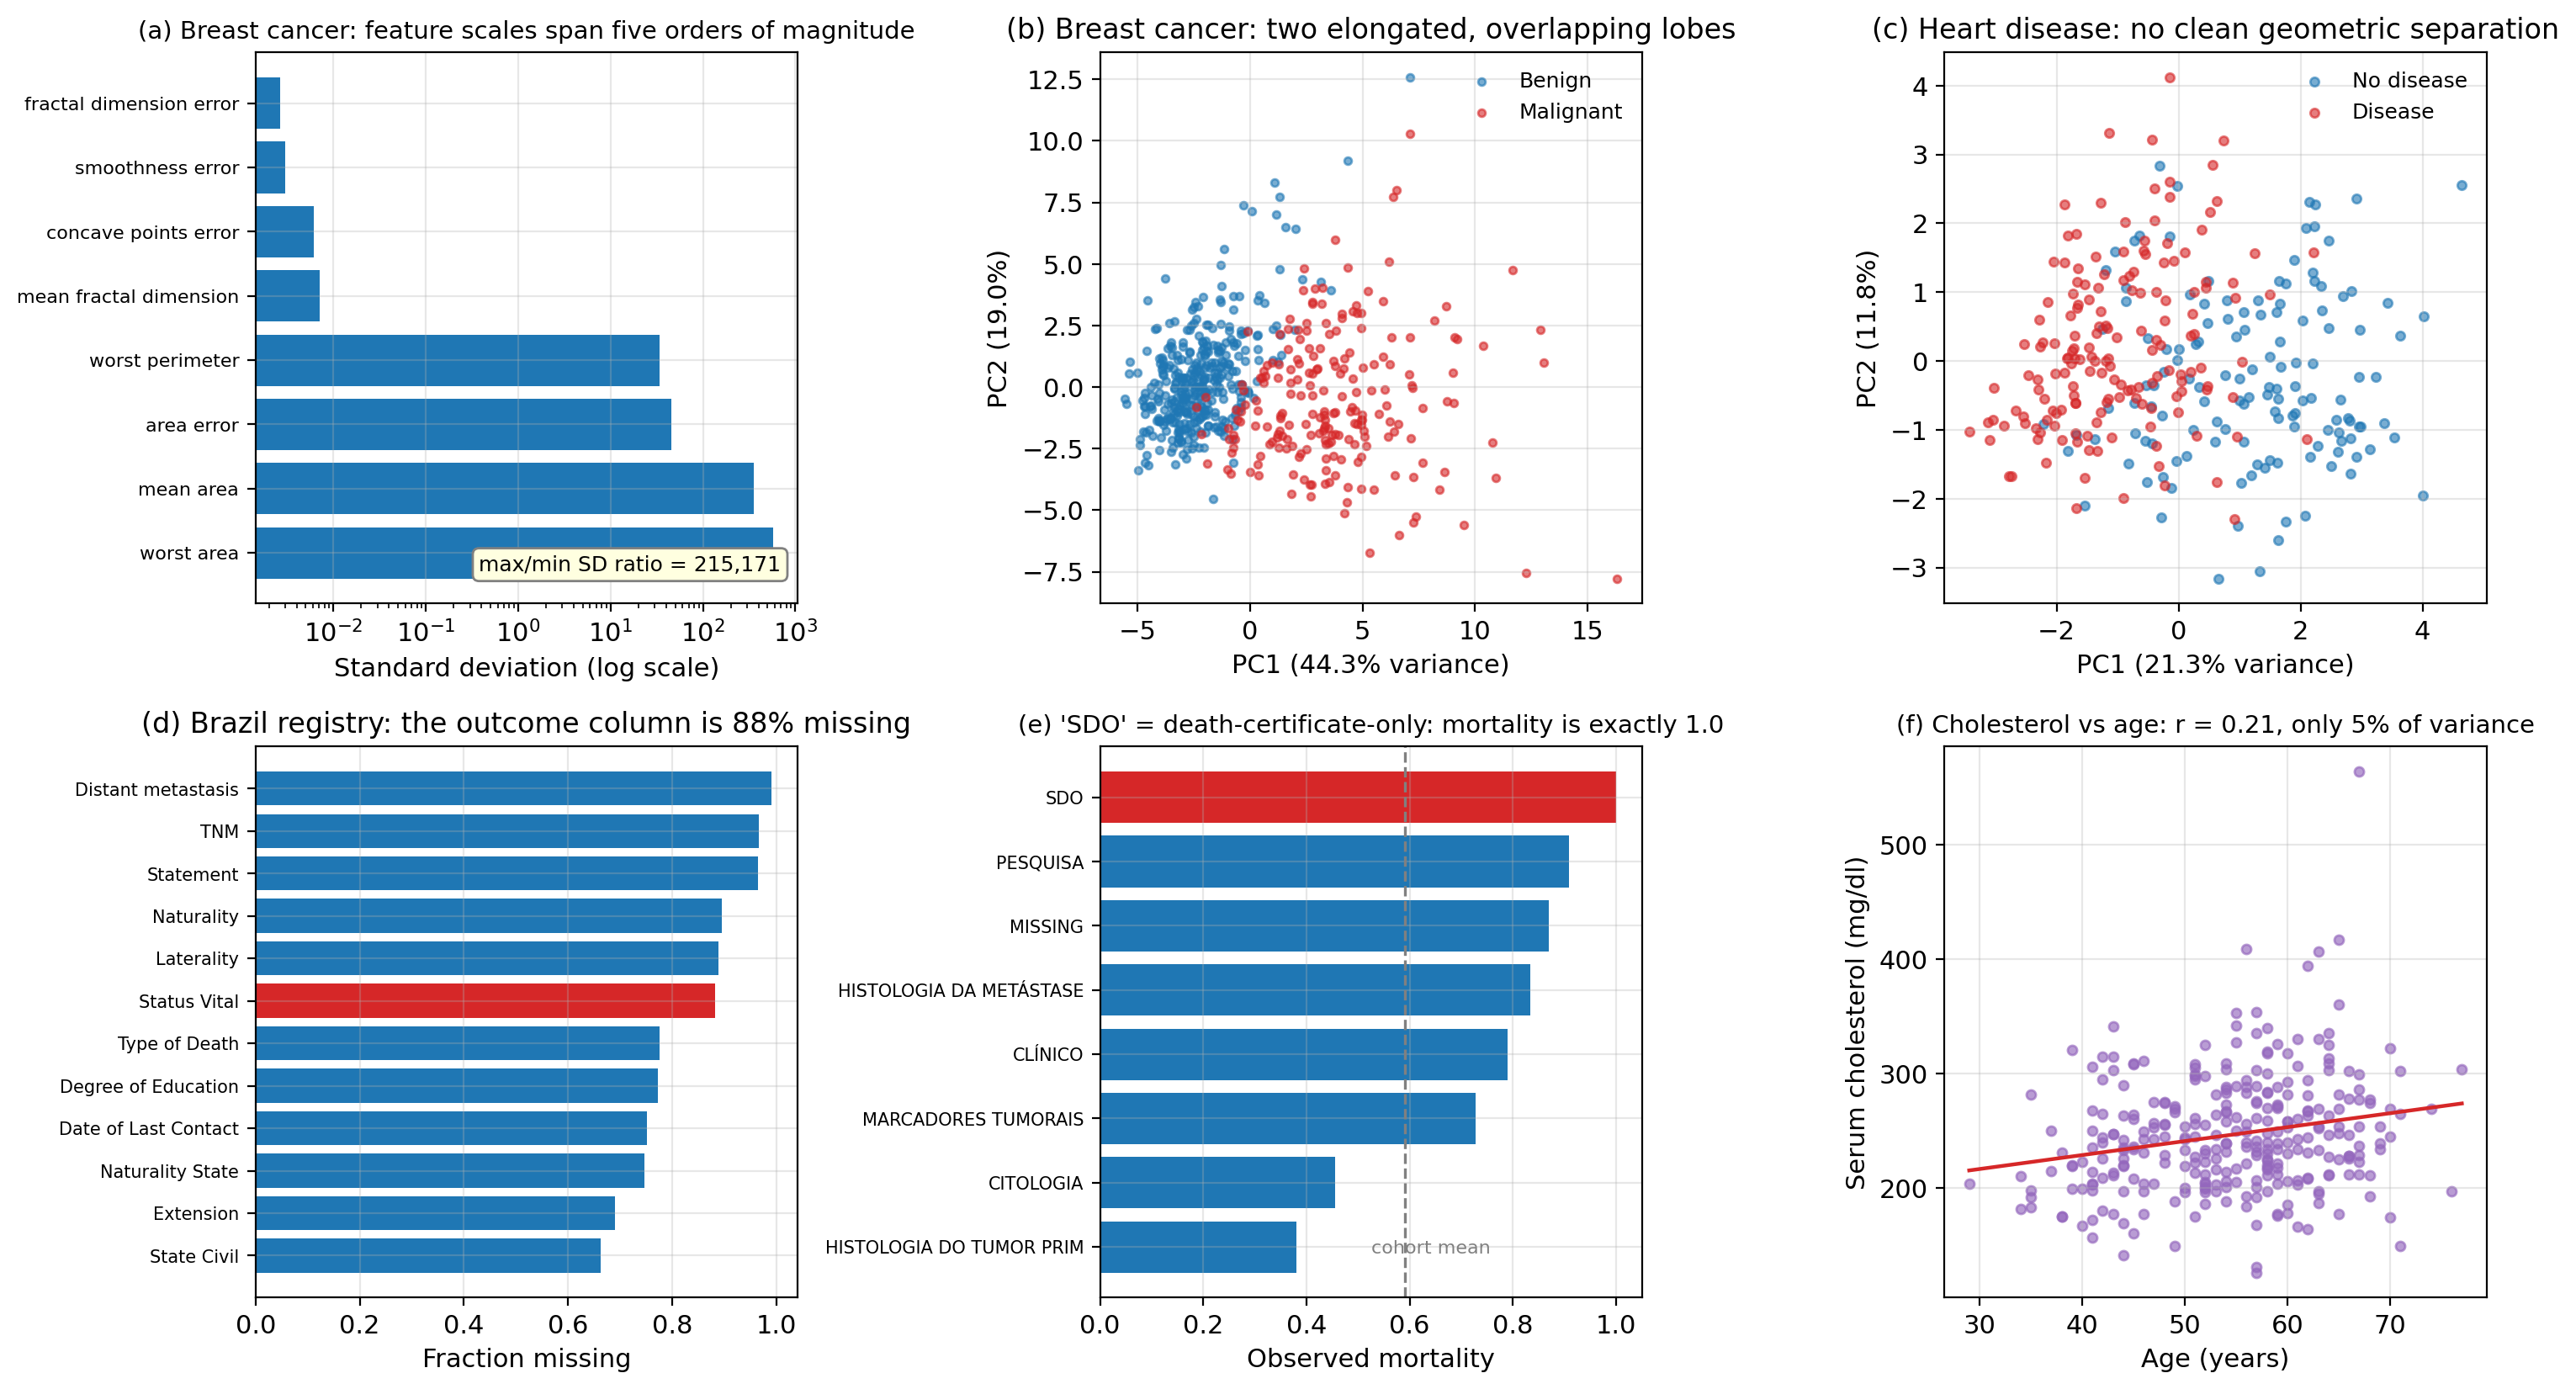

In [2]:
from week12_eda_synthesis import eda_figure
eda_figure()
from IPython.display import Image
Image('../figures/fig_week12_eda.png')

### What each panel bought

**(a)** A max/min standard-deviation ratio of 215,171 across the 30 breast-cancer features.
This single number predicts the Week 8 scaling result and the Week 10 unscaled-silhouette
trap before either model is fitted.

**(b)** Two elongated, overlapping lobes along PC1. Elongated and convex is the regime
K-Means handles well and DBSCAN handles poorly — which is exactly what Weeks 10 and 11
found. The overlap explains why no clustering exceeded ARI 0.67.

**(c)** Heart disease shows no comparable geometric separation, correctly predicting the
weaker clustering results there.

**(d)** The registry's outcome column is 88.2% missing, reducing 1,778,176 records to
209,442 usable ones.

**(e)** The leakage discovery. Mortality by diagnostic means is exactly 1.000 for the SDO
category. This panel is EDA doing something no model-fitting procedure would have done:
cross-validation cannot detect leakage, because a leaked feature generalises beautifully to
any test set drawn from the same contaminated population.

**(f)** Cholesterol against age, r = 0.21 — about 4.6% of variance. Weak but not quite the
"near zero" Milestone One reported. The corrected figure is stated here rather than carried
forward unexamined.

## Cross-week synthesis

In [3]:
from week12_eda_synthesis import synthesis
sup, unsup = synthesis()


CROSS-WEEK SYNTHESIS

Supervised results:
  Week                Model         Dataset                     Task  Test ROC-AUC  Test accuracy                         Configuration
Week 8                  KNN   Breast cancer               malignancy        0.9985         0.9650                 Manhattan (p=1), k=13
Week 8                  KNN   Heart disease          disease present        0.9094         0.7895                 Manhattan (p=1), k=27
Week 8                  KNN Brazil registry                mortality        0.8785         0.7960 Euclidean (p=2), k=31 (10k subsample)
Week 9    Gradient boosting   Breast cancer               malignancy        0.9958         0.9650                       lr=0.1, depth=3
Week 9    Gradient boosting   Heart disease          disease present        0.8711         0.7632                      lr=0.05, depth=2
Week 9 HistGradientBoosting Brazil registry mortality (clean cohort)        0.9311         0.8554     141,452 rows, native categoricals
Week 

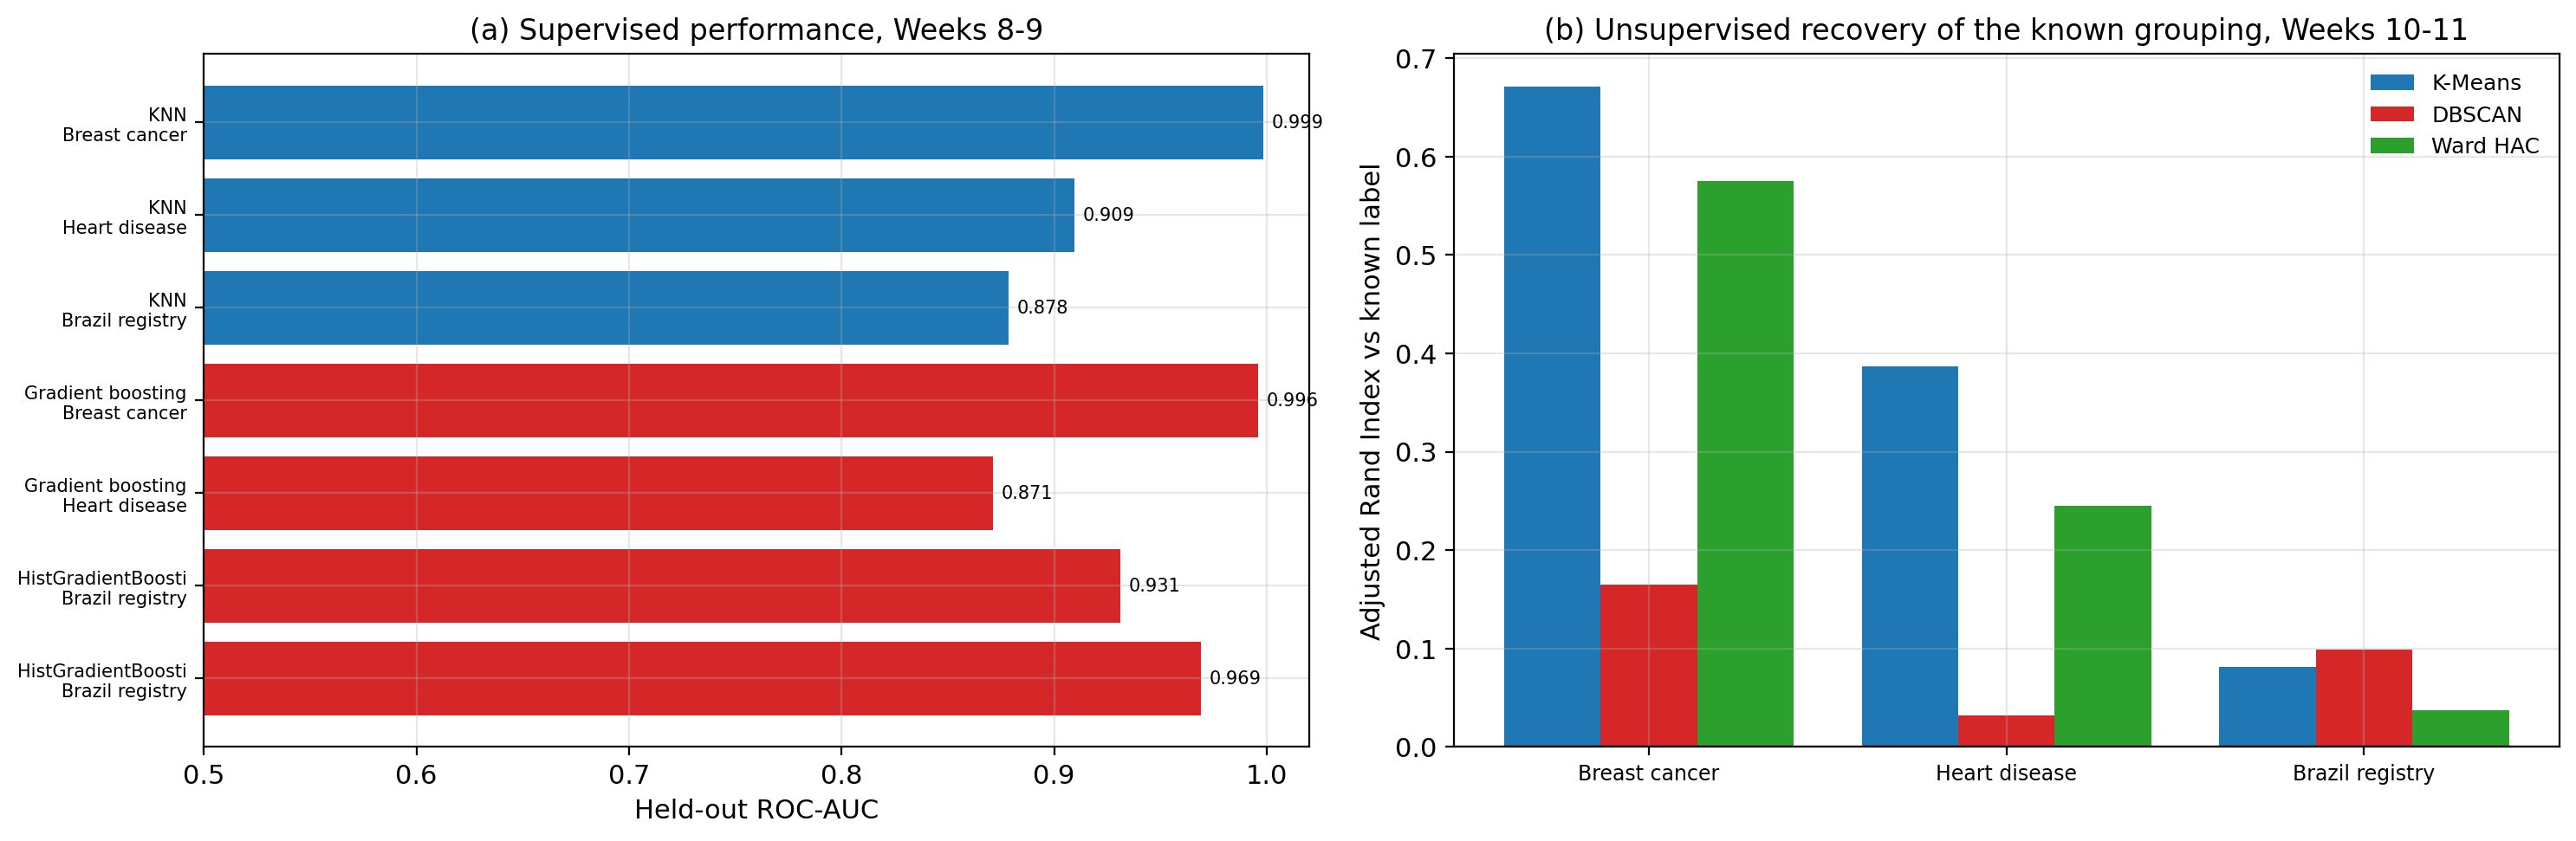

In [4]:
from IPython.display import Image
Image('../figures/fig_week12_synthesis.png')

## Conclusions across Weeks 8–11

1. **Breast-cancer malignancy is highly predictable, and the finding is now
   method-independent.** Milestone One reached ROC-AUC ≈ 0.99 with logistic regression,
   SVMs and random forests. Milestone Two adds KNN (0.9985) and gradient boosting (0.9958),
   and — more tellingly — K-Means recovers the diagnosis at 91.0% agreement with no labels
   at all. Seven model families across two milestones, three of them unsupervised, agree.

2. **Model complexity should match signal strength.** Gradient boosting, with by far the
   largest tuning budget in the project, tied the random forest on breast cancer
   (+0.0001 AUC) and lost to it on heart disease (−0.008). DBSCAN and hierarchical
   clustering, both strictly more general than K-Means, both underperformed it. Generality
   is not free.

3. **Serum cholesterol remains unlearnable, now against nonparametric models.** KNN
   regression reached test R² = 0.043 and gradient boosting 0.028. Milestone One showed
   linear and regularised models fail; Milestone Two shows local-average and boosted-tree
   models fail identically. The limit is the data.

4. **The registry's most predictive feature was an artefact.** Removing death-certificate-
   only cases and single-outcome registries cut the cohort from 209,442 to 141,452 rows and
   ROC-AUC from 0.969 to 0.931. The clean model still beats Milestone One's baseline by a
   wide margin (0.931 vs 0.73), and is the only version of the result worth reporting.

5. **Internal validation metrics can be confidently wrong.** Silhouette preferred an
   unscaled one-variable clustering (Week 10) and a 99.6%-degenerate linkage (Week 11).
   Where labels exist they should be used to audit the internal metrics; where they do not,
   internal metrics deserve much less trust than their precision suggests.